Importing Necessary Libraries

In [17]:
import pandas as pd
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
# Path Setup
metadata_path = r'D:\Capstone\OG\OG\metadata.csv'
hdf5_path = r'D:\Capstone\OG\OG\waveforms.hdf5'

In [4]:
# Dataset Loading
df = pd.read_csv(metadata_path, low_memory=False)
print(f"Metadata loaded. Total records: {len(df)}")
print(df.head())

Metadata loaded. Total records: 30
          source_id           source_origin_time  source_latitude_deg  \
0  origid=618808706  2022-07-07T16:19:51.810000Z              50.2498   
1  origid=618811604  2022-07-08T17:34:15.830000Z              50.4720   
2  origid=618827317  2022-02-07T19:34:29.500000Z              50.1900   
3  origid=618828408  2022-03-29T21:29:43.420000Z              50.0940   
4  origid=618829035  2022-04-23T01:39:41.580000Z              50.0390   

   source_longitude_deg  source_depth_km  source_magnitude split  \
0               19.1241              0.0              3.30  test   
1               18.5007              0.0              3.10  test   
2               19.0920              2.0              3.80  test   
3               18.4220             10.0              2.98  test   
4               18.5930              1.0              2.94  test   

   path_epicentral_distance_deg station_network_code station_code  ...  \
0                         1.128            

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   source_id                     30 non-null     object 
 1   source_origin_time            30 non-null     object 
 2   source_latitude_deg           30 non-null     float64
 3   source_longitude_deg          30 non-null     float64
 4   source_depth_km               30 non-null     float64
 5   source_magnitude              30 non-null     float64
 6   split                         30 non-null     object 
 7   path_epicentral_distance_deg  30 non-null     float64
 8   station_network_code          30 non-null     object 
 9   station_code                  30 non-null     object 
 10  trace_channel                 30 non-null     object 
 11  station_location_code         0 non-null      float64
 12  component_order               30 non-null     object 
 13  station

In [7]:
with h5py.File(hdf5_path, 'r') as f:
    print("Items inside 'data' group:", list(f['data'].keys()))
    
    # Let's check the first item to see its shape
    first_item_name = list(f['data'].keys())[0]
    first_item = f['data'][first_item_name]
    
    if isinstance(first_item, h5py.Dataset):
        print(f"Success! Dataset '{first_item_name}' found.")
        print(f"Shape: {first_item.shape}")
        print(f"Dtype: {first_item.dtype}")
    else:
        print(f"'{first_item_name}' is another group. We need to go deeper.")

Items inside 'data' group: ['bucket0']
Success! Dataset 'bucket0' found.
Shape: (30, 3, 30000)
Dtype: float64


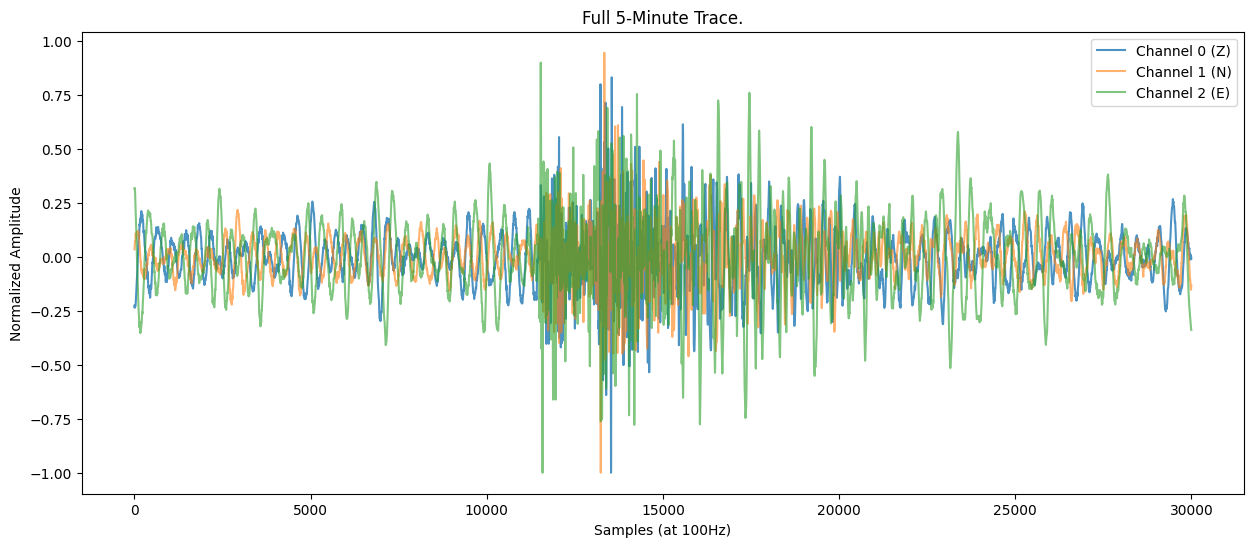

In [9]:
with h5py.File(hdf5_path, 'r') as f:
    # Pull the first event from bucket0
    # We use .T to swap axes so shape becomes (30000, 3)
    data = f['data']['bucket0'][0].T 
    
    plt.figure(figsize=(15, 6))
    plt.plot(data[:, 0], label='Channel 0 (Z)', alpha=0.8)
    plt.plot(data[:, 1], label='Channel 1 (N)', alpha=0.6)
    plt.plot(data[:, 2], label='Channel 2 (E)', alpha=0.6)
    
    plt.title("Full 5-Minute Trace.")
    plt.xlabel("Samples (at 100Hz)")
    plt.ylabel("Normalized Amplitude")
    plt.legend()
    plt.show()

In [14]:
print(data[0].shape)

(3,)


In [15]:
def prepare_training_data(dataset, window_size=40):
    X = []
    y = []
    
    for i in range(dataset.shape[0]):
        # Force the shape to (3, 30000) just in case it's flat
        raw_trace = dataset[i]
        
        # If it's flat, we reshape it. If it's already (3, 30000), this does nothing.
        if len(raw_trace.shape) == 1:
            trace = raw_trace.reshape(3, -1).T # Reshape to 3 channels, then Transpose
        else:
            trace = raw_trace.T # Shape becomes (30000, 3)
        
        # --- Labeled Noise ---
        noise_window = trace[0:window_size, :]
        if noise_window.shape == (window_size, 3):
            X.append(noise_window)
            y.append(0)
        
        # --- Labeled P-Wave ---
        # Find peak as a temporary way to find the earthquake
        p_start = np.argmax(np.abs(trace[:, 0])) 
        
        if p_start > window_size and p_start < (trace.shape[0] - window_size):
            p_window = trace[p_start : p_start + window_size, :]
            if p_window.shape == (window_size, 3):
                X.append(p_window)
                y.append(1)
                
    return np.array(X), np.array(y)

In [18]:
# The model
model = Sequential([
    # Input shape: (40 time steps, 3 features [X,Y,Z])
    LSTM(16, input_shape=(40, 3), return_sequences=False), 
    Dropout(0.2), # Prevents overfitting
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid') # Binary output: 0 (Noise) or 1 (Earthquake)
])

# 2. Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

c:\Users\HOME\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,425 (5.57 KB)

 Trainable params: 1,425 (5.57 KB)

 Non-trainable params: 0 (0.00 B)